In [37]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix,accuracy_score,roc_curve,classification_report
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

import pickle
import warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv('E_Commerce_Dataset_20000_Rows_Unique.csv')
df

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.000000,Mobile Phone,3,6.0,Debit Card,Female,3.000000,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,10.189899,Phone,1,8.0,UPI,Male,3.000000,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,10.189899,Phone,1,30.0,Debit Card,Male,2.000000,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.000000,Phone,3,15.0,Debit Card,Male,2.000000,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.000000,Phone,1,12.0,CC,Male,2.931535,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,69996,0,6.000000,Computer,3,27.0,UPI,Female,2.000000,4,Fashion,5,Married,1,0,10.0,2.0,8.0,8.0,211
19996,69997,0,13.000000,Mobile Phone,1,6.0,Debit Card,Female,4.000000,4,Fashion,3,Single,8,1,15.0,1.0,2.0,2.0,206
19997,69998,0,21.000000,Mobile Phone,1,16.0,Debit Card,Male,5.000000,4,Fashion,4,Married,4,0,15.0,2.0,1.0,4.0,232
19998,69999,0,16.000000,Mobile Phone,3,33.0,Credit Card,Male,4.000000,5,Fashion,2,Married,7,0,14.0,0.0,2.0,1.0,260


# Step2:EDA-Read and explore the data

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   20000 non-null  int64  
 1   Churn                        20000 non-null  int64  
 2   Tenure                       20000 non-null  float64
 3   PreferredLoginDevice         20000 non-null  object 
 4   CityTier                     20000 non-null  int64  
 5   WarehouseToHome              20000 non-null  float64
 6   PreferredPaymentMode         20000 non-null  object 
 7   Gender                       20000 non-null  object 
 8   HourSpendOnApp               20000 non-null  float64
 9   NumberOfDeviceRegistered     20000 non-null  int64  
 10  PreferedOrderCat             20000 non-null  object 
 11  SatisfactionScore            20000 non-null  int64  
 12  MaritalStatus                20000 non-null  object 
 13  NumberOfAddress 

In [5]:
df.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,20000.000000,20000.00000,20000.000000,20000.00000,20000.000000,20000.000000,20000.00000,20000.00000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000
mean,60000.500000,0.16560,10.242607,1.64655,15.658931,2.939127,3.68435,3.06385,4.193550,0.284950,15.69288,1.902513,3.023203,4.616493,177.135900
std,5773.647028,0.37173,8.305918,0.91349,8.543050,1.387390,1.01915,1.36615,2.840932,0.451402,3.79506,2.058276,3.036762,3.677172,48.723961
min,50001.000000,0.00000,0.000000,1.00000,3.000000,0.000000,1.00000,1.00000,0.000000,0.000000,9.00000,0.000000,0.000000,0.000000,0.000000
25%,55000.750000,0.00000,3.000000,1.00000,9.000000,2.000000,3.00000,2.00000,2.000000,0.000000,13.00000,0.000000,1.000000,2.000000,146.000000
50%,60000.500000,0.00000,9.000000,1.00000,14.000000,3.000000,4.00000,3.00000,4.000000,0.000000,15.00000,1.000000,2.000000,4.000000,163.000000
75%,65000.250000,0.00000,15.000000,3.00000,20.000000,4.000000,4.00000,4.00000,6.000000,1.000000,18.00000,3.000000,4.000000,7.000000,197.000000
max,70000.000000,1.00000,63.000000,3.00000,129.000000,6.000000,6.00000,5.00000,24.000000,1.000000,28.00000,17.000000,18.000000,48.000000,326.000000


In [6]:
df.isna().sum()

CustomerID                     0
Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64

In [7]:
df.isna().sum()*100/len(df)

CustomerID                     0.0
Churn                          0.0
Tenure                         0.0
PreferredLoginDevice           0.0
CityTier                       0.0
WarehouseToHome                0.0
PreferredPaymentMode           0.0
Gender                         0.0
HourSpendOnApp                 0.0
NumberOfDeviceRegistered       0.0
PreferedOrderCat               0.0
SatisfactionScore              0.0
MaritalStatus                  0.0
NumberOfAddress                0.0
Complain                       0.0
OrderAmountHikeFromlastYear    0.0
CouponUsed                     0.0
OrderCount                     0.0
DaySinceLastOrder              0.0
CashbackAmount                 0.0
dtype: float64

# Null value imputation

In [8]:
numerical_columns=['Tenure','WarehouseToHome','HourSpendOnApp','OrderAmountHikeFromlastYear','CouponUsed','OrderCount','DaySinceLastOrder']

for column in list(numerical_columns):
    df[column].fillna(df[column].median(),inplace=True)


In [9]:
df.isna().sum()*100/len(df)

CustomerID                     0.0
Churn                          0.0
Tenure                         0.0
PreferredLoginDevice           0.0
CityTier                       0.0
WarehouseToHome                0.0
PreferredPaymentMode           0.0
Gender                         0.0
HourSpendOnApp                 0.0
NumberOfDeviceRegistered       0.0
PreferedOrderCat               0.0
SatisfactionScore              0.0
MaritalStatus                  0.0
NumberOfAddress                0.0
Complain                       0.0
OrderAmountHikeFromlastYear    0.0
CouponUsed                     0.0
OrderCount                     0.0
DaySinceLastOrder              0.0
CashbackAmount                 0.0
dtype: float64

In [10]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print("")

CustomerID
[50001 50002 50003 ... 69998 69999 70000]

Churn
[1 0]

Tenure
[ 4.         10.18989937  0.         13.         11.          9.
 19.         20.         14.          8.         18.          5.
  2.         30.          1.         23.          3.         29.
  6.         26.         28.          7.         24.         25.
 10.         15.         22.         27.         16.         12.
 21.         17.         50.         60.         31.         51.
 61.         52.         32.         33.         62.         63.        ]

PreferredLoginDevice
['Mobile Phone' 'Phone' 'Computer']

CityTier
[3 1 2]

WarehouseToHome
[  6.           8.          30.          15.          12.
  22.          11.           9.          31.          18.
  13.          20.          29.          28.          26.
  14.          15.63989589  10.          27.          17.
  23.          33.          19.          35.          24.
  16.          25.          32.          34.           5.
  21.         126.   

In [11]:
df['PreferredLoginDevice'].value_counts()

PreferredLoginDevice
Mobile Phone    9732
Computer        5869
Phone           4399
Name: count, dtype: int64

In [12]:
### As mobile phones and phones are same,Let's merge them.

In [13]:
category_mapping={'Phone':'Mobile Phone'}
df['PreferredLoginDevice']=df['PreferredLoginDevice'].replace(category_mapping)
print(df['PreferredLoginDevice'].value_counts())

PreferredLoginDevice
Mobile Phone    14131
Computer         5869
Name: count, dtype: int64


In [14]:
df.replace({"PreferredLoginDevice":{'Mobile Phone':0,'Computer':1}},inplace=True)

In [15]:
df['PreferredPaymentMode'].value_counts()

PreferredPaymentMode
Debit Card          8160
Credit Card         5427
E wallet            2159
UPI                 1464
COD                 1285
CC                   963
Cash on Delivery     542
Name: count, dtype: int64

In [16]:
### As Credit Card and CC are same, Let's merge them.
### As COD and Cash on Delivery are same Let;s merge them.

In [17]:
category_mapping={'CC':'Credit Card'}
df['PreferredPaymentMode']=df['PreferredPaymentMode'].replace(category_mapping)
print(df['PreferredPaymentMode'].value_counts())

PreferredPaymentMode
Debit Card          8160
Credit Card         6390
E wallet            2159
UPI                 1464
COD                 1285
Cash on Delivery     542
Name: count, dtype: int64


In [18]:
category_mapping={'Cash on Delivery':'COD'}
df['PreferredPaymentMode']=df['PreferredPaymentMode'].replace(category_mapping)
print(df['PreferredPaymentMode'].value_counts())

PreferredPaymentMode
Debit Card     8160
Credit Card    6390
E wallet       2159
COD            1827
UPI            1464
Name: count, dtype: int64


In [19]:
df['Gender'].value_counts()

Gender
Male      12063
Female     7937
Name: count, dtype: int64

In [20]:
df.replace({"Gender":{'Male':0,'Female':1}},inplace=True)

In [21]:
df['PreferedOrderCat'].value_counts()

PreferedOrderCat
Laptop & Accessory    7276
Mobile Phone          4532
Fashion               2997
Mobile                2845
Grocery               1462
Others                 888
Name: count, dtype: int64

In [22]:
category_mapping={'Mobile':'Mobile Phone'}
df['PreferedOrderCat']=df['PreferedOrderCat'].replace(category_mapping)
print(df['PreferedOrderCat'].value_counts())

PreferedOrderCat
Mobile Phone          7377
Laptop & Accessory    7276
Fashion               2997
Grocery               1462
Others                 888
Name: count, dtype: int64


In [23]:
df['MaritalStatus'].value_counts()

MaritalStatus
Married     10640
Single       6380
Divorced     2980
Name: count, dtype: int64

In [24]:
df['Churn'].value_counts()

Churn
0    16688
1     3312
Name: count, dtype: int64

--- Churn Distribution (Percentages) ---
|   Churn |   proportion |
|--------:|-------------:|
|       0 |        83.44 |
|       1 |        16.56 |


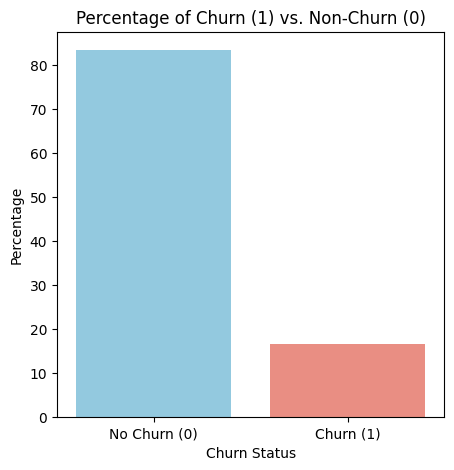

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Calculate the percentage of Churn (1) and Non-Churn (0)
churn_counts = df['Churn'].value_counts(normalize=True) * 100

# 2. Print the breakdown
print("--- Churn Distribution (Percentages) ---")
# Use to_markdown() for clean printing if running in an interpreter
print(churn_counts.to_markdown()) 

# 3. Create the bar plot for visualization
plt.figure(figsize=(5, 5))

# Use the calculated percentages for the Y-axis and Churn status (0, 1) for the X-axis
sns.barplot(x=churn_counts.index, y=churn_counts.values, palette=['skyblue', 'salmon'])

# Set plot labels and titles
plt.title('Percentage of Churn (1) vs. Non-Churn (0)')
plt.ylabel('Percentage')
plt.xlabel('Churn Status')
plt.xticks([0, 1], ['No Churn (0)', 'Churn (1)']) # Relabel X-ticks for clarity

plt.show()

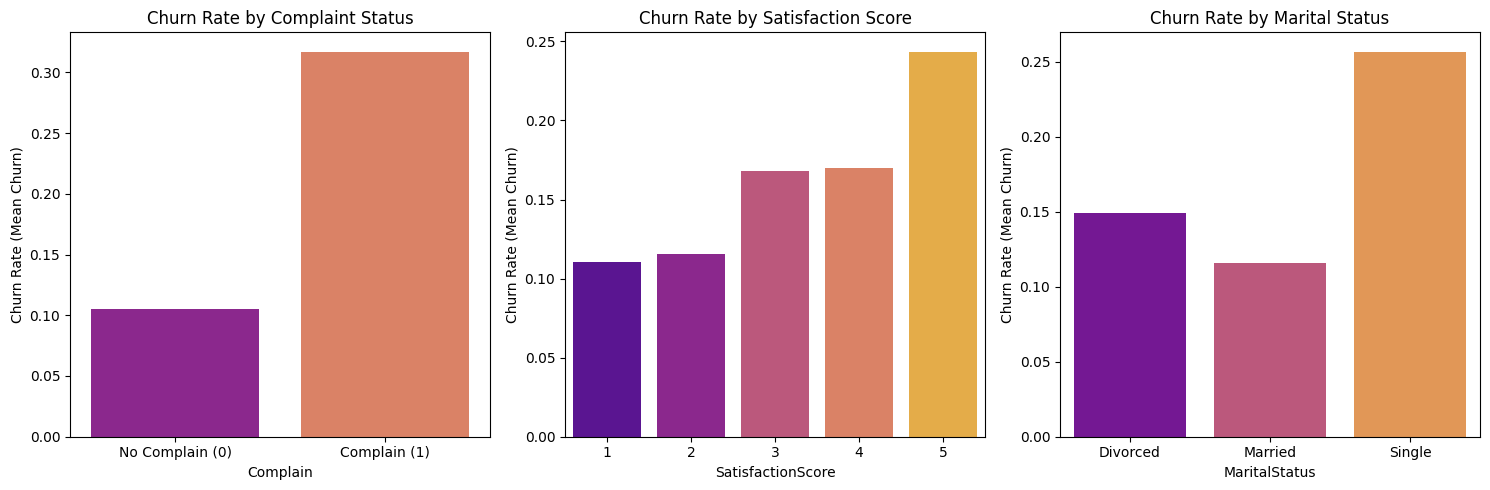

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- Plot 1: Complain ---
# Calculate the mean 'Churn' for each value in 'Complain'
plot_data_complain = df.groupby('Complain')['Churn'].mean().reset_index()
sns.barplot(x='Complain', y='Churn', data=plot_data_complain, ax=axes[0], palette='plasma')
axes[0].set_title('Churn Rate by Complaint Status')
axes[0].set_ylabel('Churn Rate (Mean Churn)')
axes[0].set_xticklabels(['No Complain (0)', 'Complain (1)'])

# --- Plot 2: SatisfactionScore ---
plot_data_satisfaction = df.groupby('SatisfactionScore')['Churn'].mean().reset_index()
sns.barplot(x='SatisfactionScore', y='Churn', data=plot_data_satisfaction, ax=axes[1], palette='plasma')
axes[1].set_title('Churn Rate by Satisfaction Score')
axes[1].set_ylabel('Churn Rate (Mean Churn)')

# --- Plot 3: MaritalStatus ---
plot_data_marital = df.groupby('MaritalStatus')['Churn'].mean().reset_index()
sns.barplot(x='MaritalStatus', y='Churn', data=plot_data_marital, ax=axes[2], palette='plasma')
axes[2].set_title('Churn Rate by Marital Status')
axes[2].set_ylabel('Churn Rate (Mean Churn)')

plt.tight_layout()
plt.show()

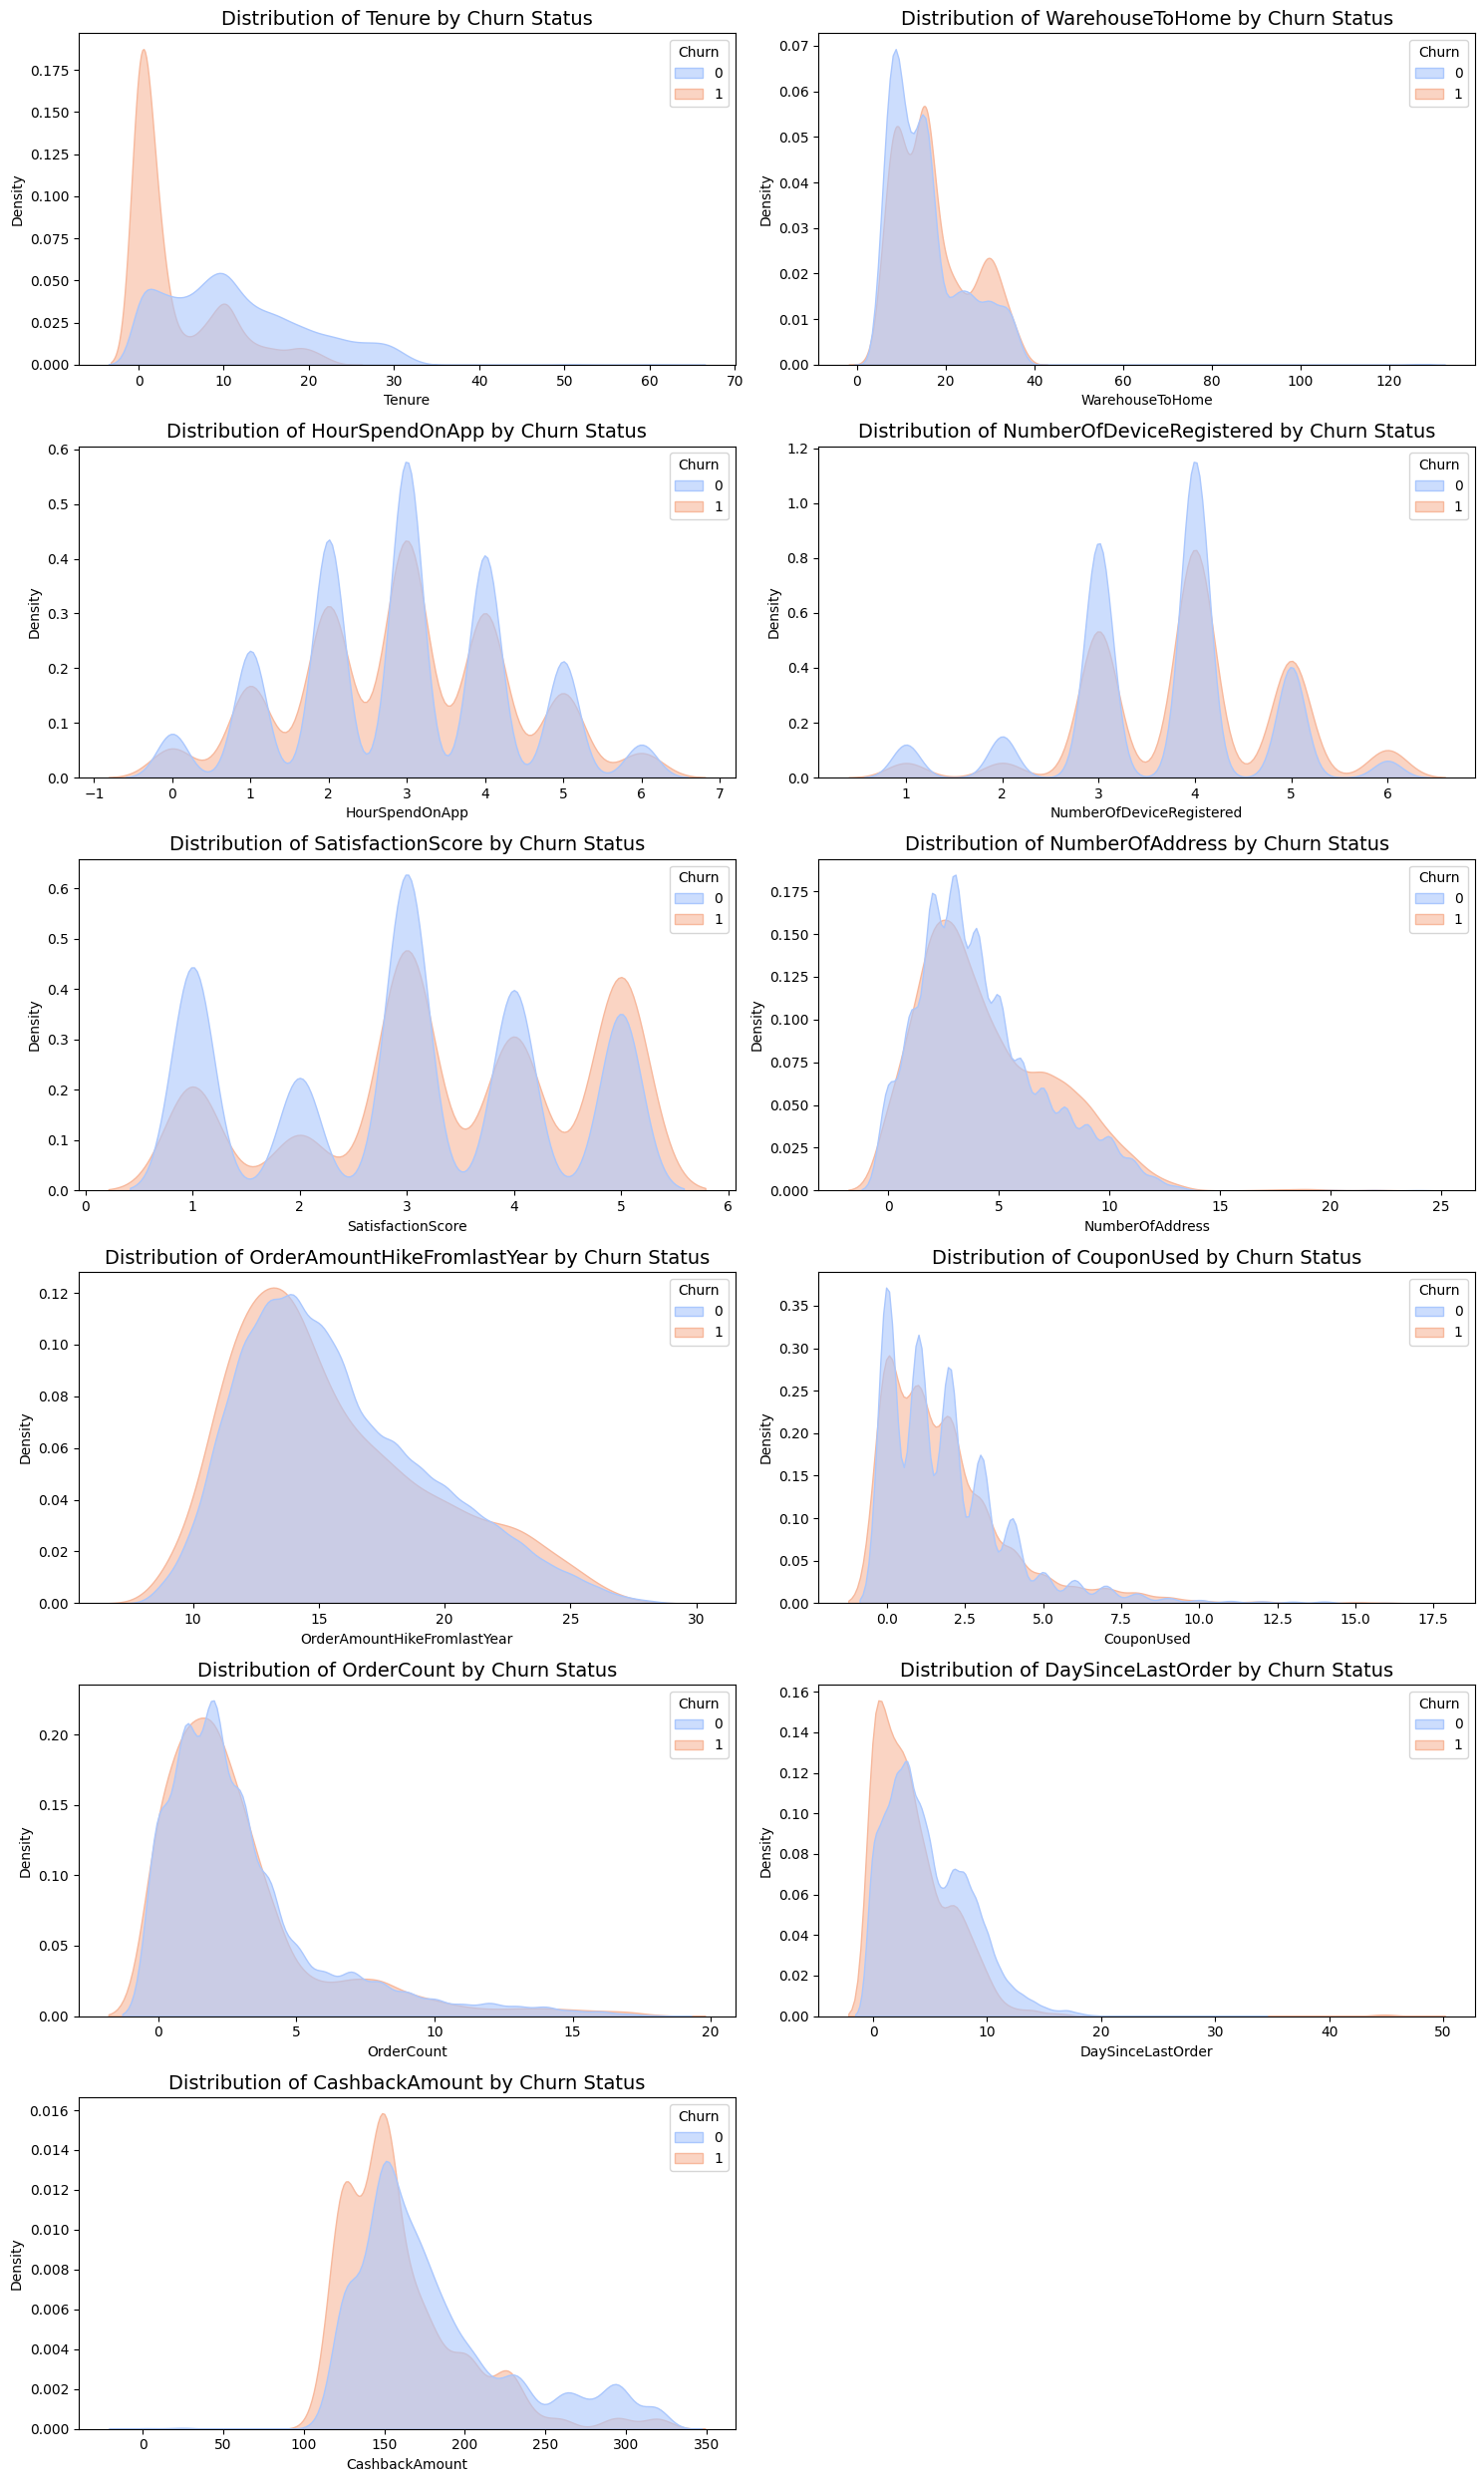

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of all numerical columns to visualize against 'Churn'
numerical_columns = [
    'Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered',
    'SatisfactionScore', 'NumberOfAddress', 'OrderAmountHikeFromlastYear',
    'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount'
]

# Create a figure with 6 rows and 2 columns to display all 11 plots
plt.figure(figsize=(15, 25))

for i, col in enumerate(numerical_columns):
    # i+1 for subplot indexing
    plt.subplot(6, 2, i + 1)
    
    # Use sns.kdeplot:
    # hue='Churn' separates the plot into two curves (Churn=0 and Churn=1)
    # common_norm=False allows the area under each curve to represent the proportion of its group
    sns.kdeplot(data=df, x=col, hue='Churn', fill=True, common_norm=False, palette='coolwarm', alpha=0.6)
    plt.title(f'Distribution of {col} by Churn Status', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Density')

plt.tight_layout() # Ensures plots and titles do not overlap
plt.show()

In [28]:
categorial_features=['PreferredPaymentMode','PreferedOrderCat','MaritalStatus']

In [29]:
numerical_features=['Tenure','PreferredLoginDevice','CityTier','WarehouseToHome','PreferredPaymentMode','Gender','HourSpendOnApp','NumberOfDeviceRegistered','SatisfactionScore','NumberOfAddress','Complain','OrderAmountHikeFromlastYear','CouponUsed','OrderCount','DaySinceLastOrder','CashbackAmount']


In [30]:
df_features=df[numerical_features+categorial_features+['Churn']]
df_features.head(10)

,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,PreferredPaymentMode,PreferedOrderCat,MaritalStatus,Churn
0,4.000000,0,3,6.0,Debit Card,1,3.000000,3,2,9,1,11.0,1.0,1.0,5.0,160,Debit Card,Laptop & Accessory,Single,1
1,10.189899,0,1,8.0,UPI,0,3.000000,4,3,7,1,15.0,0.0,1.0,0.0,121,UPI,Mobile Phone,Single,1
2,10.189899,0,1,30.0,Debit Card,0,2.000000,4,3,6,1,14.0,0.0,1.0,3.0,120,Debit Card,Mobile Phone,Single,1
3,0.000000,0,3,15.0,Debit Card,0,2.000000,4,5,8,0,23.0,0.0,1.0,3.0,134,Debit Card,Laptop & Accessory,Single,1
4,0.000000,0,1,12.0,Credit Card,0,2.931535,3,5,3,0,11.0,1.0,1.0,3.0,130,Credit Card,Mobile Phone,Single,1
5,0.000000,1,1,22.0,Debit Card,1,3.000000,5,5,2,1,22.0,4.0,6.0,7.0,139,Debit Card,Mobile Phone,Single,1
6,10.189899,0,3,11.0,COD,0,2.000000,3,2,4,0,14.0,0.0,1.0,0.0,121,COD,Laptop & Accessory,Divorced,1
7,10.189899,0,1,6.0,Credit Card,0,3.000000,3,2,3,1,16.0,2.0,2.0,0.0,123,Credit Card,Mobile Phone,Divorced,1
8,13.000000,0,3,9.0,E wallet,0,2.931535,4,3,2,1,14.0,0.0,1.0,2.0,127,E wallet,Mobile Phone,Divorced,1
9,10.189899,0,1,31.0,Debit Card,0,2.000000,5,3,2,0,12.0,1.0,1.0,1.0,123,Debit Card,Mobile Phone,Single,1


In [31]:
# 1.Separate features (X) and target (y)
X = df_features.drop('Churn', axis=1)
y = df_features['Churn']

# Perform One-Hot Encoding on all object columns
# drop_first=True removes one category per feature, avoiding multicollinearity
X_encoded = pd.get_dummies(X, drop_first=True, dtype=int)

print("--- Final Encoded Features (Total Columns) ---")
print(f"Total features created: {X_encoded.shape[1]}")
print("\nFirst 5 column names (showing new dummy features):")
print(X_encoded.columns[:5].tolist())

--- Final Encoded Features (Total Columns) ---
Total features created: 29

First 5 column names (showing new dummy features):
['Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'Gender']


In [32]:
# Display the first 5 rows of the encoded DataFrame
X_encoded.head()


,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,Gender,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,...,PreferredPaymentMode_Credit Card,PreferredPaymentMode_Debit Card,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single
0,4.000000,0,3,6.0,1,3.000000,3,2,9,1,...,0,1,0,0,0,1,0,0,0,1
1,10.189899,0,1,8.0,0,3.000000,4,3,7,1,...,0,0,0,1,0,0,1,0,0,1
2,10.189899,0,1,30.0,0,2.000000,4,3,6,1,...,0,1,0,0,0,0,1,0,0,1
3,0.000000,0,3,15.0,0,2.000000,4,5,8,0,...,0,1,0,0,0,1,0,0,0,1
4,0.000000,0,1,12.0,0,2.931535,3,5,3,0,...,1,0,0,0,0,0,1,0,0,1


In [33]:
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', 1000)        # Prevent line wrapping
X_encoded.head()


,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,Gender,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,PreferredPaymentMode_Credit Card,PreferredPaymentMode_Debit Card,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,PreferredPaymentMode_Credit Card,PreferredPaymentMode_Debit Card,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single
0,4.000000,0,3,6.0,1,3.000000,3,2,9,1,11.0,1.0,1.0,5.0,160,0,1,0,0,0,1,0,0,0,1,0,0,0,1
1,10.189899,0,1,8.0,0,3.000000,4,3,7,1,15.0,0.0,1.0,0.0,121,0,0,0,1,0,0,0,1,0,0,1,0,0,1
2,10.189899,0,1,30.0,0,2.000000,4,3,6,1,14.0,0.0,1.0,3.0,120,0,1,0,0,0,1,0,0,0,0,1,0,0,1
3,0.000000,0,3,15.0,0,2.000000,4,5,8,0,23.0,0.0,1.0,3.0,134,0,1,0,0,0,1,0,0,0,1,0,0,0,1
4,0.000000,0,1,12.0,0,2.931535,3,5,3,0,11.0,1.0,1.0,3.0,130,1,0,0,0,1,0,0,0,0,0,1,0,0,1


converting pandas into numpy 

In [34]:
# ------------------------------
# 2. Train/Test Split
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# Convert to NumPy arrays for XGBoost safety
X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()
y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()

In [35]:
!pip install xgboost


Defaulting to user installation because normal site-packages is not writeable


In [38]:
# ------------------------------
# 3. Handle Class Imbalance (Optional but recommended)
# ------------------------------
# Compute scale_pos_weight for XGBoost
scale_pos_weight = (y_train_np == 0).sum() / (y_train_np == 1).sum()
print(f"Scale Pos Weight: {scale_pos_weight:.2f}")

# ------------------------------
# 4. Initialize XGBoost Model
# ------------------------------
xgb_model = XGBClassifier(
    random_state=42,
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight  # balances the classes
)

# ------------------------------
# 5. Train Model
# ------------------------------
print("Training XGBoost Model...")
model_xgb = xgb_model.fit(X_train_np, y_train_np)
print("Training Complete.")

# ------------------------------
# 6. Make Predictions
# ------------------------------
y_pred = model_xgb.predict(X_test_np)
y_proba = model_xgb.predict_proba(X_test_np)[:, 1]

# ------------------------------
# 7. Evaluate Model
# ------------------------------
accuracy = accuracy_score(y_test_np, y_pred)
conf_matrix = confusion_matrix(y_test_np, y_pred)
class_report = classification_report(y_test_np, y_pred)

print("\n" + "="*50)
print("             FINAL XGBOOST MODEL EVALUATION")
print("="*50)
print(f"Test Accuracy: {accuracy*100:.2f}%")
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report (Focus on Churn=1):\n", class_report)
print("="*50)

# ------------------------------
# 8. Save Model and Feature Names
# ------------------------------
with open('best_xgb_churn_model.pkl', 'wb') as file:
    pickle.dump(model_xgb, file)

feature_names = X_encoded.columns.tolist()
with open('feature_names.pkl', 'wb') as file:
    pickle.dump(feature_names, file)

print("\nModel and feature names saved for deployment.")


Scale Pos Weight: 5.04
Training XGBoost Model...
Training Complete.

             FINAL XGBOOST MODEL EVALUATION
Test Accuracy: 91.70%

Confusion Matrix:
 [[3061  277]
 [  55  607]]

Classification Report (Focus on Churn=1):
               precision    recall  f1-score   support

           0       0.98      0.92      0.95      3338
           1       0.69      0.92      0.79       662

    accuracy                           0.92      4000
   macro avg       0.83      0.92      0.87      4000
weighted avg       0.93      0.92      0.92      4000


Model and feature names saved for deployment.


In [39]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle

# NOTE: For Random Forest, class imbalance is typically handled using the 'class_weight' parameter, 
# not a computed scale_pos_weight, which is XGBoost specific.

# ------------------------------
# 3. Handle Class Imbalance
# ------------------------------
# Use class_weight='balanced' in the classifier initialization.
# This automatically adjusts weights inversely proportional to class frequencies.
print("Class Imbalance will be handled using class_weight='balanced' in RF initialization.")

# ------------------------------
# 4. Initialize Random Forest Model
# ------------------------------
rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=200,
    max_depth=10, # A reasonable starting depth
    class_weight='balanced', # balances the classes
    n_jobs=-1 # Use all processors
)

# ------------------------------
# 5. Train Model
# ------------------------------
print("Training Random Forest Model...")
model_rf = rf_model.fit(X_train_np, y_train_np)
print("Training Complete.")

# ------------------------------
# 6. Make Predictions
# ------------------------------
y_pred = model_rf.predict(X_test_np)
y_proba = model_rf.predict_proba(X_test_np)[:, 1]

# ------------------------------
# 7. Evaluate Model
# ------------------------------
accuracy = accuracy_score(y_test_np, y_pred)
conf_matrix = confusion_matrix(y_test_np, y_pred)
class_report = classification_report(y_test_np, y_pred)

print("\n" + "="*50)
print("             FINAL RANDOM FOREST MODEL EVALUATION")
print("="*50)
print(f"Test Accuracy: {accuracy*100:.2f}%")
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report (Focus on Churn=1):\n", class_report)
print("="*50)

# ------------------------------
# 8. Save Model and Feature Names
# ------------------------------
with open('best_rf_churn_model.pkl', 'wb') as file:
    pickle.dump(model_rf, file)

# feature_names is assumed to be defined as in your original code snippet
# feature_names = X_encoded.columns.tolist()
# with open('feature_names.pkl', 'wb') as file:
#     pickle.dump(feature_names, file)

print("\nModel and feature names saved for deployment.")

Class Imbalance will be handled using class_weight='balanced' in RF initialization.
Training Random Forest Model...
Training Complete.

             FINAL RANDOM FOREST MODEL EVALUATION
Test Accuracy: 94.62%

Confusion Matrix:
 [[3174  164]
 [  51  611]]

Classification Report (Focus on Churn=1):
               precision    recall  f1-score   support

           0       0.98      0.95      0.97      3338
           1       0.79      0.92      0.85       662

    accuracy                           0.95      4000
   macro avg       0.89      0.94      0.91      4000
weighted avg       0.95      0.95      0.95      4000


Model and feature names saved for deployment.


In [40]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle

# ------------------------------
# 3. Handle Class Imbalance
# ------------------------------
# Use class_weight='balanced' in the classifier initialization.
print("Class Imbalance will be handled using class_weight='balanced' in LR initialization.")

# ------------------------------
# 4. Initialize Logistic Regression Model
# ------------------------------
lr_model = LogisticRegression(
    random_state=42,
    solver='liblinear',        # Good for small datasets and for 'l1' penalty
    max_iter=1000,             # Increase iterations for convergence
    class_weight='balanced'    # balances the classes
)

# ------------------------------
# 5. Train Model
# ------------------------------
print("Training Logistic Regression Model...")
model_lr = lr_model.fit(X_train_np, y_train_np)
print("Training Complete.")

# ------------------------------
# 6. Make Predictions
# ------------------------------
y_pred = model_lr.predict(X_test_np)
y_proba = model_lr.predict_proba(X_test_np)[:, 1]

# ------------------------------
# 7. Evaluate Model
# ------------------------------
accuracy = accuracy_score(y_test_np, y_pred)
conf_matrix = confusion_matrix(y_test_np, y_pred)
class_report = classification_report(y_test_np, y_pred)

print("\n" + "="*50)
print("        FINAL LOGISTIC REGRESSION MODEL EVALUATION")
print("="*50)
print(f"Test Accuracy: {accuracy*100:.2f}%")
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report (Focus on Churn=1):\n", class_report)
print("="*50)

# ------------------------------
# 8. Save Model and Feature Names
# ------------------------------
with open('best_lr_churn_model.pkl', 'wb') as file:
    pickle.dump(model_lr, file)

# feature_names is assumed to be defined as in your original code snippet
# feature_names = X_encoded.columns.tolist()
# with open('feature_names.pkl', 'wb') as file:
#     pickle.dump(feature_names, file)

print("\nModel and feature names saved for deployment.")

Class Imbalance will be handled using class_weight='balanced' in LR initialization.
Training Logistic Regression Model...
Training Complete.

        FINAL LOGISTIC REGRESSION MODEL EVALUATION
Test Accuracy: 79.22%

Confusion Matrix:
 [[2635  703]
 [ 128  534]]

Classification Report (Focus on Churn=1):
               precision    recall  f1-score   support

           0       0.95      0.79      0.86      3338
           1       0.43      0.81      0.56       662

    accuracy                           0.79      4000
   macro avg       0.69      0.80      0.71      4000
weighted avg       0.87      0.79      0.81      4000


Model and feature names saved for deployment.


In [41]:
import numpy as np
import pickle
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ------------------------------
# 3. Handle Class Imbalance
# ------------------------------
# Compute scale_pos_weight (used as class_weights for binary classification in CatBoost)
# Assuming y_train_np is a NumPy array of labels
positive_count = (y_train_np == 1).sum()
negative_count = (y_train_np == 0).sum()

# CatBoost uses the ratio of non-minority class to minority class as the weight for the minority class
# The churn (1) class is the minority class.
class_weight_ratio = negative_count / positive_count
print(f"Negative (0) Count: {negative_count}")
print(f"Positive (1) Count: {positive_count}")
print(f"Class Weight Ratio (Weight for Churn=1): {class_weight_ratio:.2f}")

# CatBoost class_weights is a list/array/dict of weights for the classes, 
# in the order of class labels (0, 1).
# Weight for class 0 is 1.0 (default), weight for class 1 is the calculated ratio.
class_weights = [1.0, class_weight_ratio]


# ------------------------------
# 4. Initialize CatBoost Model
# ------------------------------
catboost_model = CatBoostClassifier(
    random_state=42,
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='Logloss',
    verbose=0, # Suppress CatBoost output during training
    class_weights=class_weights # balances the classes
)

# ------------------------------
# 5. Train Model
# ------------------------------
print("Training CatBoost Model...")
# CatBoost can handle feature names if X_train_np was a DataFrame, but here we assume numpy arrays.
model_catboost = catboost_model.fit(X_train_np, y_train_np)
print("Training Complete.")

# ------------------------------
# 6. Make Predictions
# ------------------------------
y_pred = model_catboost.predict(X_test_np)
# CatBoost predict_proba returns columns in the order of class labels (0, 1)
y_proba = model_catboost.predict_proba(X_test_np)[:, 1]

# ------------------------------
# 7. Evaluate Model
# ------------------------------
accuracy = accuracy_score(y_test_np, y_pred)
conf_matrix = confusion_matrix(y_test_np, y_pred)
class_report = classification_report(y_test_np, y_pred)

print("\n" + "="*50)
print("             FINAL CATBOOST MODEL EVALUATION")
print("="*50)
print(f"Test Accuracy: {accuracy*100:.2f}%")
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report (Focus on Churn=1):\n", class_report)
print("="*50)

# ------------------------------
# 8. Save Model and Feature Names
# ------------------------------
with open('best_catboost_churn_model.pkl', 'wb') as file:
    pickle.dump(model_catboost, file)

# feature_names is assumed to be defined from X_encoded.columns.tolist()
# with open('feature_names.pkl', 'wb') as file:
#     pickle.dump(feature_names, file)

print("\nModel and feature names saved for deployment.")

Negative (0) Count: 13350
Positive (1) Count: 2650
Class Weight Ratio (Weight for Churn=1): 5.04
Training CatBoost Model...
Training Complete.

             FINAL CATBOOST MODEL EVALUATION
Test Accuracy: 89.42%

Confusion Matrix:
 [[2969  369]
 [  54  608]]

Classification Report (Focus on Churn=1):
               precision    recall  f1-score   support

           0       0.98      0.89      0.93      3338
           1       0.62      0.92      0.74       662

    accuracy                           0.89      4000
   macro avg       0.80      0.90      0.84      4000
weighted avg       0.92      0.89      0.90      4000


Model and feature names saved for deployment.


In [42]:
import numpy as np
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier # Requires 'catboost' library
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle

# --- Assume y_train_np is available for calculating class weights ---
positive_count = (y_train_np == 1).sum()
negative_count = (y_train_np == 0).sum()
xgb_scale_pos_weight = negative_count / positive_count
cat_class_weight_ratio = negative_count / positive_count
cat_class_weights = [1.0, cat_class_weight_ratio]

# ----------------------------------------------------
# 1. Initialize Base Models with best-known parameters
# ----------------------------------------------------

# Model 1: Random Forest (Your current best)
rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    n_jobs=-1
)

# Model 2: XGBoost
xgb_model = XGBClassifier(
    random_state=42,
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=xgb_scale_pos_weight
)

# Model 3: CatBoost
cat_model = CatBoostClassifier(
    random_state=42,
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='Logloss',
    verbose=0,
    class_weights=cat_class_weights
)

# ----------------------------------------------------
# 2. Initialize the Voting Classifier (Simple Stacking)
# ----------------------------------------------------
# Using 'soft' voting (based on class probabilities) often gives better results,
# but 'hard' voting (majority class prediction) is simpler. We'll use 'soft' here.
ensemble_model = VotingClassifier(
    estimators=[
        ('rf', rf_model),
        ('xgb', xgb_model),
        ('cat', cat_model)
    ],
    voting='soft', # Use 'soft' voting to average predicted probabilities
    n_jobs=-1
)

# ----------------------------------------------------
# 3. Train the Ensemble Model
# ----------------------------------------------------
print("Training Ensemble Voting Classifier...")
model_ensemble = ensemble_model.fit(X_train_np, y_train_np)
print("Training Complete.")

# ----------------------------------------------------
# 4. Make Predictions
# ----------------------------------------------------
y_pred = model_ensemble.predict(X_test_np)
# Note: Predict_proba works for 'soft' voting
y_proba = model_ensemble.predict_proba(X_test_np)[:, 1]

# ----------------------------------------------------
# 5. Evaluate Model
# ----------------------------------------------------
accuracy = accuracy_score(y_test_np, y_pred)
conf_matrix = confusion_matrix(y_test_np, y_pred)
class_report = classification_report(y_test_np, y_pred)

print("\n" + "="*50)
print("       FINAL ENSEMBLE VOTING CLASSIFIER EVALUATION")
print("="*50)
print(f"Test Accuracy: {accuracy*100:.2f}%")
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report (Focus on Churn=1):\n", class_report)
print("="*50)

# ----------------------------------------------------
# 6. Save Model
# ----------------------------------------------------
with open('best_ensemble_churn_model.pkl', 'wb') as file:
    pickle.dump(model_ensemble, file)

# The feature names file is still valid from previous steps
# with open('feature_names.pkl', 'wb') as file:
#     pickle.dump(feature_names, file)

print("\nEnsemble model saved for deployment.")

Training Ensemble Voting Classifier...
Training Complete.

       FINAL ENSEMBLE VOTING CLASSIFIER EVALUATION
Test Accuracy: 92.30%

Confusion Matrix:
 [[3080  258]
 [  50  612]]

Classification Report (Focus on Churn=1):
               precision    recall  f1-score   support

           0       0.98      0.92      0.95      3338
           1       0.70      0.92      0.80       662

    accuracy                           0.92      4000
   macro avg       0.84      0.92      0.88      4000
weighted avg       0.94      0.92      0.93      4000


Ensemble model saved for deployment.


In [46]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle

# NOTE: For Random Forest, class imbalance is typically handled using the 'class_weight' parameter, 
# not a computed scale_pos_weight, which is XGBoost specific.

# ------------------------------
# 3. Handle Class Imbalance
# ------------------------------
# Use class_weight='balanced' in the classifier initialization.
# This automatically adjusts weights inversely proportional to class frequencies.
print("Class Imbalance will be handled using class_weight='balanced' in RF initialization.")

# ------------------------------
# 4. Initialize Random Forest Model
# ------------------------------
rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=200,
    max_depth=10, # A reasonable starting depth
    class_weight='balanced', # balances the classes
    n_jobs=-1 # Use all processors
)

# ------------------------------
# 5. Train Model
# ------------------------------
print("Training Random Forest Model...")
model_rf = rf_model.fit(X_train_np, y_train_np)
print("Training Complete.")

# ------------------------------
# 6. Make Predictions
# ------------------------------
y_pred = model_rf.predict(X_test_np)
y_proba = model_rf.predict_proba(X_test_np)[:, 1]

# ------------------------------
# 7. Evaluate Model
# ------------------------------
accuracy = accuracy_score(y_test_np, y_pred)
conf_matrix = confusion_matrix(y_test_np, y_pred)
class_report = classification_report(y_test_np, y_pred)

print("\n" + "="*50)
print("             FINAL RANDOM FOREST MODEL EVALUATION")
print("="*50)
print(f"Test Accuracy: {accuracy*100:.2f}%")
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report (Focus on Churn=1):\n", class_report)
print("="*50)

# ------------------------------
# 8. Save Model and Feature Names
# ------------------------------
with open('best_rf_churn_model.pkl', 'wb') as file:
    pickle.dump(model_rf, file)

# feature_names is assumed to be defined as in your original code snippet
# feature_names = X_encoded.columns.tolist()
# with open('feature_names.pkl', 'wb') as file:
#     pickle.dump(feature_names, file)

print("\nModel and feature names saved for deployment.")

Class Imbalance will be handled using class_weight='balanced' in RF initialization.
Training Random Forest Model...
Training Complete.

             FINAL RANDOM FOREST MODEL EVALUATION
Test Accuracy: 94.62%

Confusion Matrix:
 [[3174  164]
 [  51  611]]

Classification Report (Focus on Churn=1):
               precision    recall  f1-score   support

           0       0.98      0.95      0.97      3338
           1       0.79      0.92      0.85       662

    accuracy                           0.95      4000
   macro avg       0.89      0.94      0.91      4000
weighted avg       0.95      0.95      0.95      4000


Model and feature names saved for deployment.


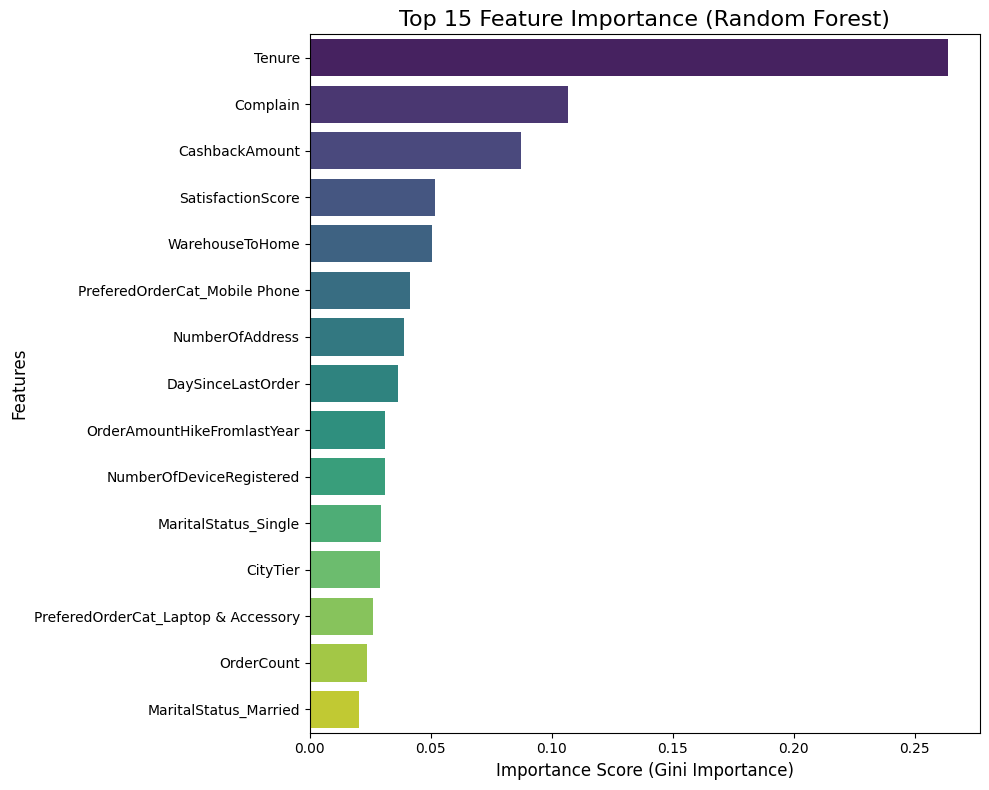

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NOTE: This code assumes that:
# 1. 'rf_model' holds your final fitted Random Forest model.
# 2. 'feature_names' is the list of all 33 column names (X_encoded.columns.tolist()).

# 1. Calculate Feature Importance
# The .feature_importances_ attribute extracts the feature importance scores directly from the RF model.
feature_imp = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)

# 2. Setup the Plot
# We'll plot the top 15 features for clarity, but you can adjust this number.
top_features_to_plot = 15 
plt.figure(figsize=(10, 8)) 

# Create the bar plot
sns.barplot(
    x=feature_imp[:top_features_to_plot], 
    y=feature_imp.index[:top_features_to_plot], 
    palette='viridis'
)

# 3. Add Titles and Labels
plt.title(f"Top {top_features_to_plot} Feature Importance (Random Forest)", fontsize=16)
plt.xlabel("Importance Score (Gini Importance)", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.tight_layout() # Ensures labels don't get cut off
plt.show()